In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import sys

# Setting the root folder
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# --- Other Imports
from src.import_dataframe import import_dataframe
from src.plot_meldefined_magnitudes_per_class import plot_meldefined_magnitudes_per_class
from src.plot_acoustic_features import plot_acoustic_features
from src.build_X import build_X
from src.run_cv_experiment import run_cv_experiment
from src.extra_plot_results_bar import extra_plot_results_bar
from src.extra_build_table_accuracies import extra_build_table_accuracies
from src.extra_plot_3_confusion_matrices import extra_plot_3_confusion_matrices



In [2]:
# import dataframe
df = import_dataframe("mysMEEI")


# Verify columns
print(df.columns)

Index(['file', 'age', 'gender', 'group', 'class', 'localJitter',
       'localShimmer', 'HNR', 'MFBM'],
      dtype='object')


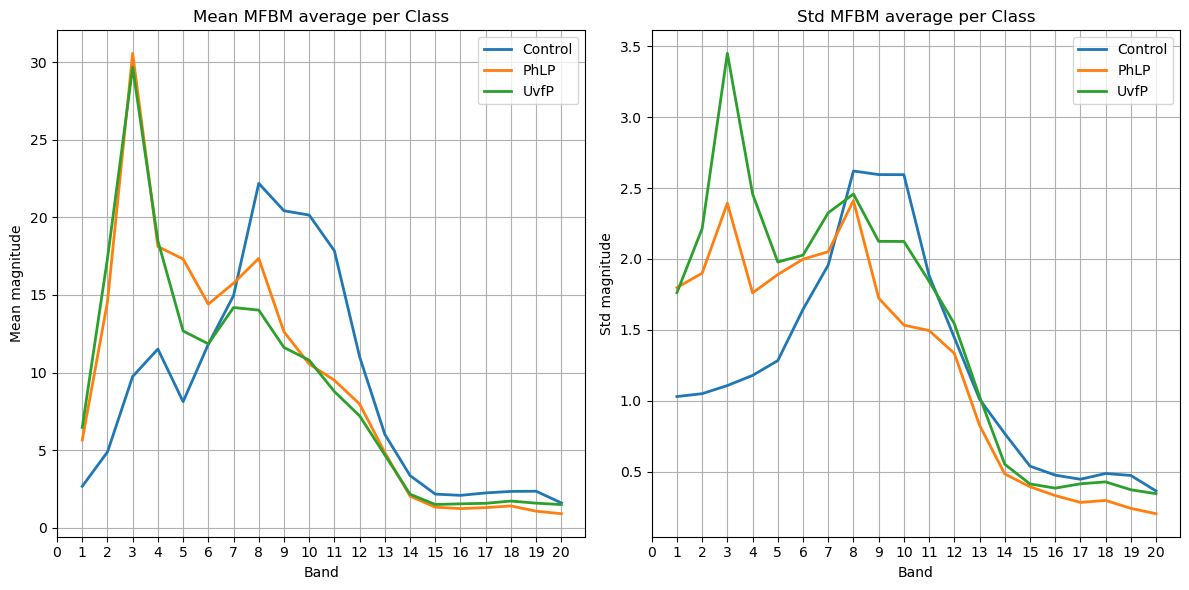

In [3]:
# Calculating band magnitude mean and std dev and adding to dataframe
# These are the features used in the Article

mean_list = []
std_list = []

for mfbm in df['MFBM']:

    # mfbm shape: (n_filters, n_frames)

    mean_bands = np.mean(mfbm, axis=1)  # (20,)
    std_bands = np.std(mfbm, axis=1)    # (20,)

    mean_list.append(mean_bands)
    std_list.append(std_bands)

df['mean_MFBM'] = mean_list
df['std_MFBM'] = std_list


# The Article joined the edema and nodules classes into one, PhLP
# Merging edema and nodules into 'PhLP' class
df.loc[df['group'].isin(['edema', 'nodulo']), 'group'] = 'PhLP'
df.loc[df['group'].isin(['UVFP']), 'group'] = 'UvfP'
df.loc[df['group'].isin(['control']), 'group'] = 'Control'
#df.loc[df['class'] == 3, 'class'] = 1



# Recalculate class codes from scratch after merge
df['class'] = pd.Categorical(df['group']).codes


# Plotting mean and std magintudes per band, per class
plot_meldefined_magnitudes_per_class(
    df,
    save_path = "../results/figures/02mel_bands_per_class.png"
)


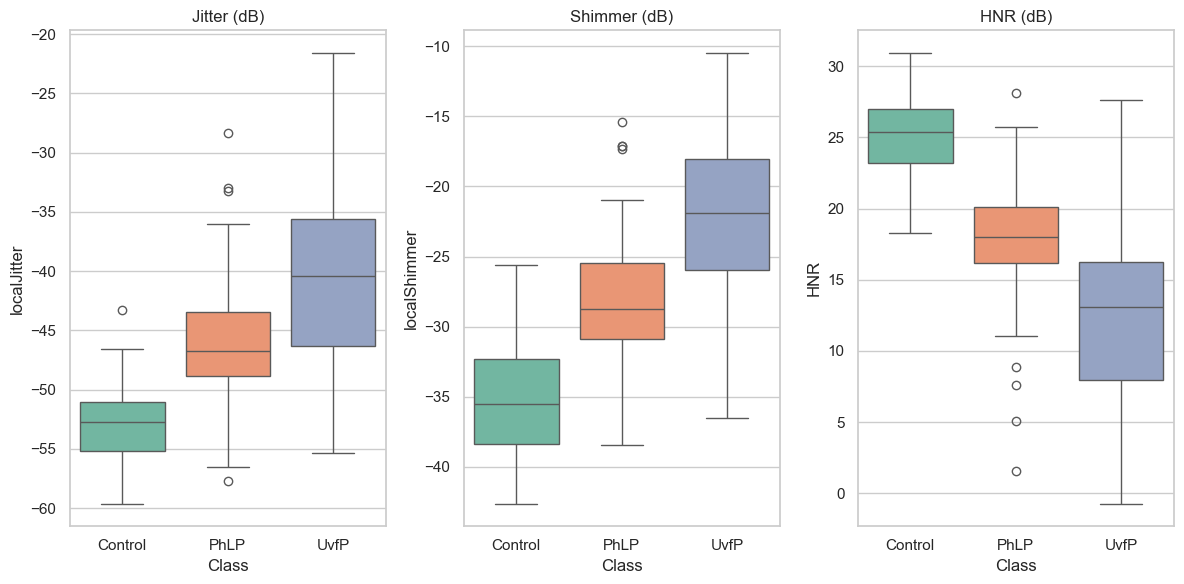

In [4]:
# Show acoustic features per class boxplots
# Jitter and shimmer were converted to dB
# for better visualization

features = [
    ("localJitter", "Jitter (dB)"),
    ("localShimmer", "Shimmer (dB)"),
    ("HNR", "HNR (dB)")
]

plot_acoustic_features(df,
                       features,
                       save_path = "../results/figures/03acoustic_features_per_class.png"
                      )

In [5]:
# ------------------------------------------------------------------
# Experiment grid
# ------------------------------------------------------------------

# Feature sets to evaluate — each will be tested on every task
feature_sets = ["acoustic", "spectral", "all"]

# Classification tasks — each entry maps a task name to the two groups
# involved. None means all classes are used (3-class classification).
tasks = {
    "Control_vs_PhLP": ["Control", "PhLP"],
    "Control_vs_UVFP": ["Control", "UvfP"],
    "PhLP_vs_UVFP":    ["PhLP", "UvfP"],
    "All_classes":     None                 # all three classes
}

# ------------------------------------------------------------------
# Run all experiments
# ------------------------------------------------------------------
results = []

for task_name, groups in tasks.items():

    # Filter dataset to the relevant classes for this task.
    # For the 3-class task, the full dataset is used as-is.
    if groups is None:
        df_task = df.copy()
    else:
        df_task = df[df["group"].isin(groups)].copy()

    # Encode group labels as integer class codes.
    # pd.Categorical preserves a consistent mapping within each task.
    df_task["class"] = pd.Categorical(df_task["group"]).codes

    X = build_X(df_task)       # feature matrix — shape (n_samples, 27)
    y = df_task["class"].values

    # Run cross-validation for each feature set
    for feat in feature_sets:

        metrics = run_cv_experiment(
            X, y,
            feature_set=feat,
            print_report=True
        )

        # Store results alongside task and feature set identifiers
        results.append({
            "task":     task_name,
            "features": feat,
            **metrics
        })

# ------------------------------------------------------------------
# Collect all results into a single DataFrame for analysis and export
# ------------------------------------------------------------------
results_df = pd.DataFrame(results)

Accuracy : 0.8466043956043957
Std Acc  : 0.010007357515543623
Precision: 0.8033716825596398
Recall   : 0.8106111111088592
F1       : 0.806862875534337
AUC      : 0.9034318181818182

Confusion Matrix (average over iterations)
 [[29.182  6.818]
 [ 7.141 47.859]]

Normalised Confusion Matrix (average over iterations)
 [[0.81061111 0.18938889]
 [0.12983636 0.87016364]]

Accuracy : 0.8601428571428573
Std Acc  : 0.015835126705309805
Precision: 0.8454778752994956
Recall   : 0.7917222222200228
F1       : 0.8173238317497731
AUC      : 0.9233156565656566

Confusion Matrix (average over iterations)
 [[28.502  7.498]
 [ 5.229 49.771]]

Normalised Confusion Matrix (average over iterations)
 [[0.79172222 0.20827778]
 [0.09507273 0.90492727]]

Accuracy : 0.9302857142857145
Std Acc  : 0.012294262688790364
Precision: 0.8980391065169966
Recall   : 0.9293333333307519
F1       : 0.9132295688307948
AUC      : 0.9648853535353535

Confusion Matrix (average over iterations)
 [[33.456  2.544]
 [ 3.8   51.2  ]]

In [6]:
# Show results
print(results_df)

# Export results
results_df.to_csv("../results/metrics/summary.csv", sep=";", index=False)


               task  features  accuracy_mean  accuracy_std  precision  \
0   Control_vs_PhLP  acoustic       0.846604      0.010007   0.803372   
1   Control_vs_PhLP  spectral       0.860143      0.015835   0.845478   
2   Control_vs_PhLP       all       0.930286      0.012294   0.898039   
3   Control_vs_UVFP  acoustic       0.902436      0.007150   0.821907   
4   Control_vs_UVFP  spectral       0.862489      0.013238   0.799647   
5   Control_vs_UVFP       all       0.927340      0.011659   0.851751   
6      PhLP_vs_UVFP  acoustic       0.698212      0.012999   0.666222   
7      PhLP_vs_UVFP  spectral       0.627372      0.029939   0.602537   
8      PhLP_vs_UVFP       all       0.742832      0.019284   0.727618   
9       All_classes  acoustic       0.676530      0.011057   0.805450   
10      All_classes  spectral       0.657792      0.020481   0.876537   
11      All_classes       all       0.761456      0.012829   0.890701   

      recall        f1       auc  \
0   0.810611  

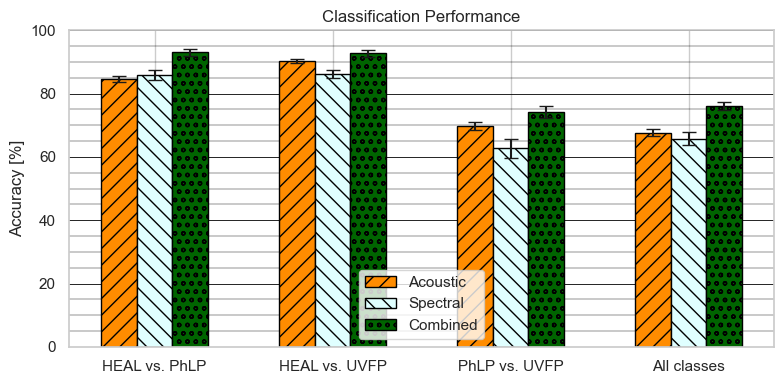

In [7]:
# Plot accuracies bar graph
extra_plot_results_bar(results_df, "../results/figures/04accuracies_bar.png")

In [8]:
# Make, show and save Accuracies Table

table1 = extra_build_table_accuracies(results_df)

table1.to_csv("../results/metrics/accuracies.csv", index=False, sep=";")

print(table1)

  Classification   HE vs. PhLP   HE vs. UVFP PhLP vs. UVFP       3-Class  \
0       Acoustic  84.66 ± 1.00  90.24 ± 0.72  69.82 ± 1.30  67.65 ± 1.11   
1       Spectral  86.01 ± 1.58  86.25 ± 1.32  62.74 ± 2.99  65.78 ± 2.05   
2       Combined  93.03 ± 1.23  92.73 ± 1.17  74.28 ± 1.93  76.15 ± 1.28   

  HE vs. All (*) PhLP vs. All (*) UVFP vs. All (*)  
0   88.08 ± 0.62     70.32 ± 1.12     76.91 ± 0.94  
1   88.53 ± 1.02     70.94 ± 2.05     72.09 ± 2.10  
2   91.80 ± 0.66     79.48 ± 1.34     81.01 ± 1.23  


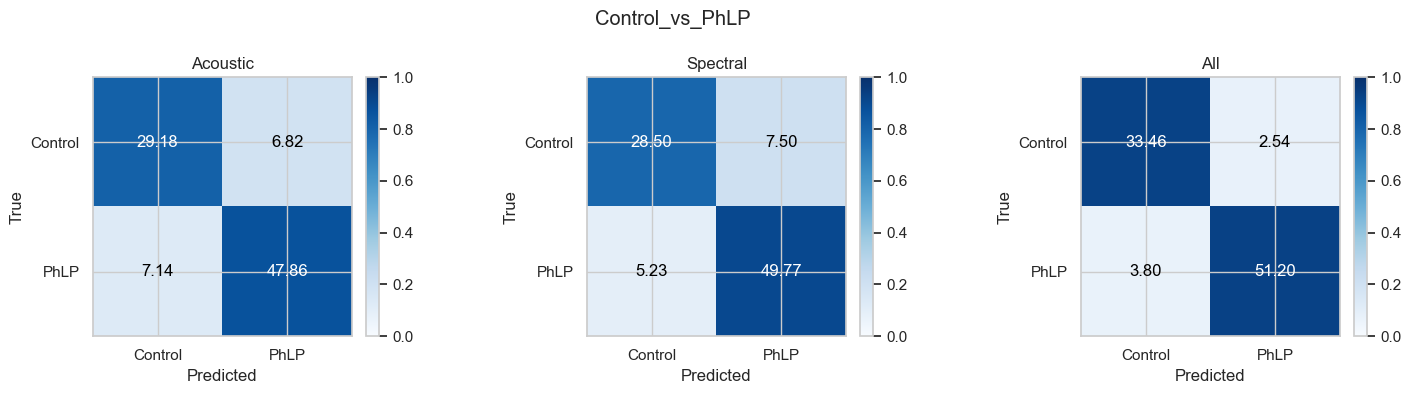

In [9]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="Control_vs_PhLP",
    class_names=["Control", "PhLP"],
    save_path="../results/figures/05_ConfMatr_Control_vs_PhLP.png"
)

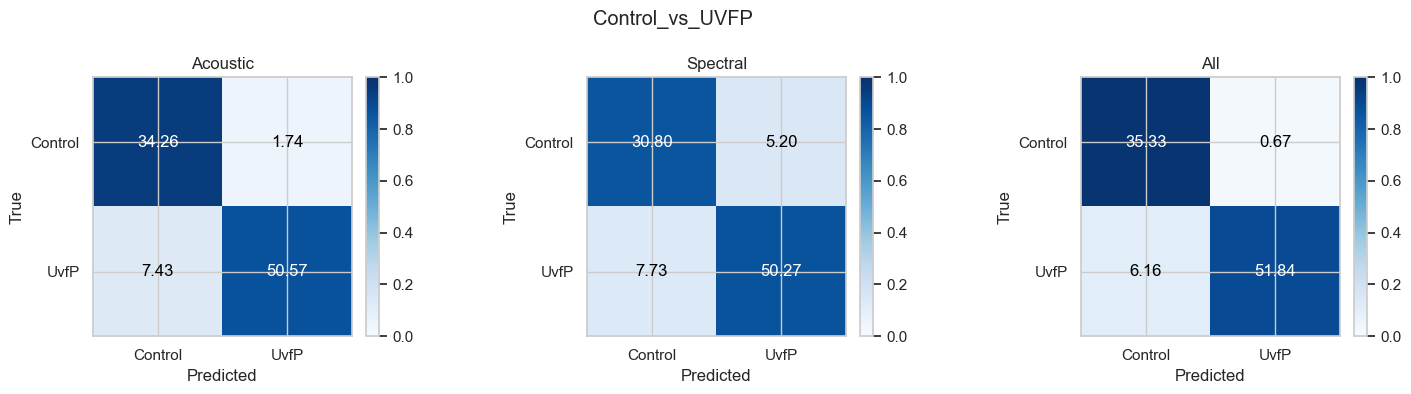

In [10]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="Control_vs_UVFP",
    class_names=["Control", "UvfP"],
    save_path="../results/figures/06_ConfMatr_Control_vs_UvfP.png"
)


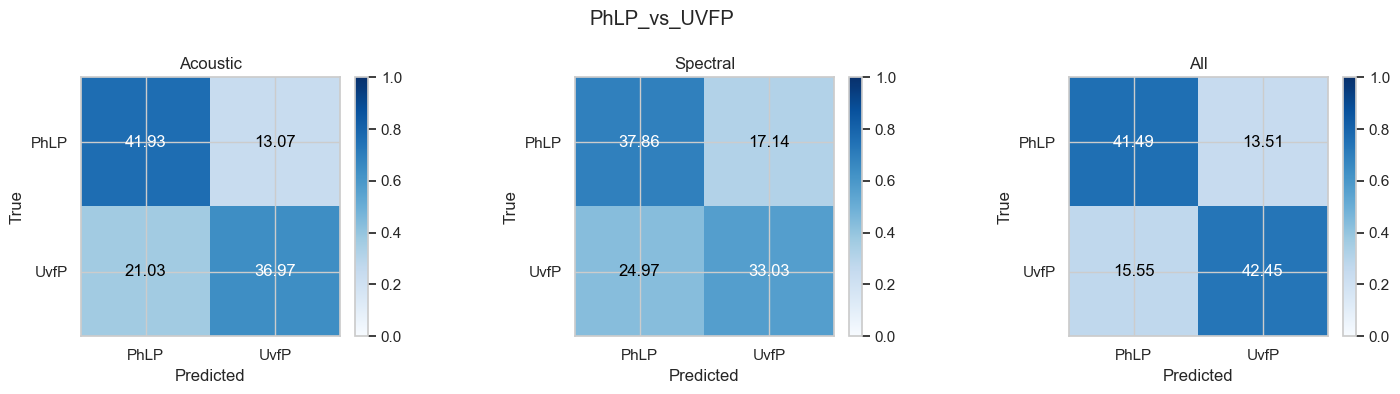

In [11]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="PhLP_vs_UVFP",
    class_names=["PhLP", "UvfP"],
    save_path="../results/figures/07_ConfMatr_PhLP_vs_UvfP.png"
)

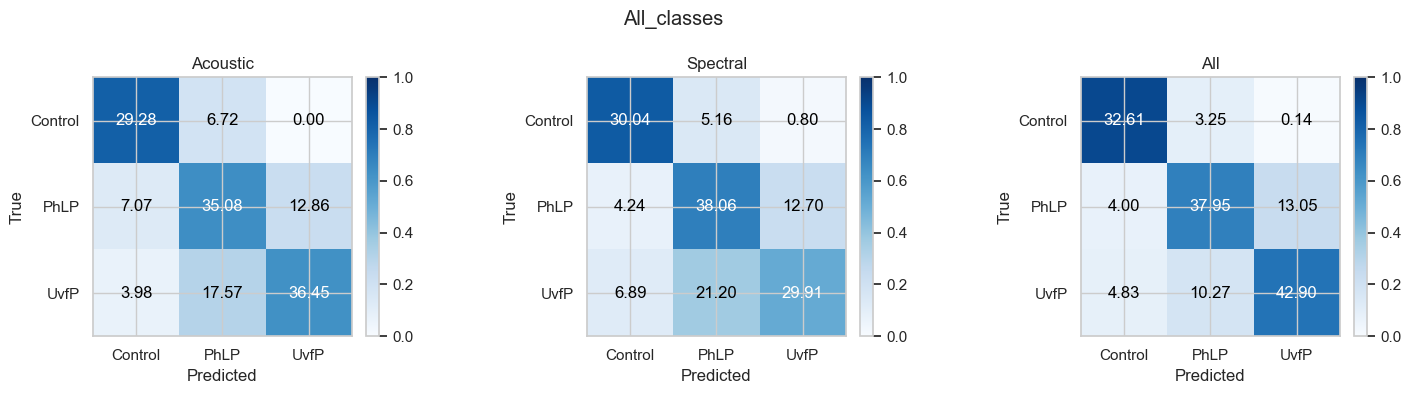

In [12]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="All_classes",
    class_names=["Control", "PhLP", "UvfP"],
    save_path="../results/figures/08_ConfMatr_3_classes.png"
)